In [1]:
import pandas as pd

df = pd.read_csv("./creditcard.csv")

print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
0    284315
1       492
Name: Class, dtype: int64


In [2]:
df['Hour'] = (df['Time'] // 3600) % 24
df['DayPart'] = df['Hour'] // 6

df.drop('Time', axis=1, inplace=True)

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

/home/talentum/.local/lib/python3.6/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/home/talentum/.local/lib/python3.6/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                       n_jobs=-1, random_state=42)

In [7]:
probs = model.predict_proba(X_test)[:,1]

In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56860     4]
 [   24    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.76      0.84        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)
print("ROC AUC:", roc_auc)

ROC AUC: 0.9517725069769043


PR AUC: 0.8613698069563794


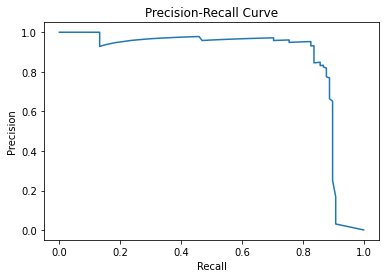

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, probs)

pr_auc = average_precision_score(y_test, probs)

print("PR AUC:", pr_auc)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [14]:
import joblib

In [15]:
joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']